In [104]:
import pandas as pd
import warnings
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
df = pd.read_csv(r'insurance.csv')
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [106]:
df.tail(2)

,age,sex,bmi,children,smoker,region,charges
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [107]:
smoker_palette = {'yes': 'lightcoral', 'no': 'green'}

In [108]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


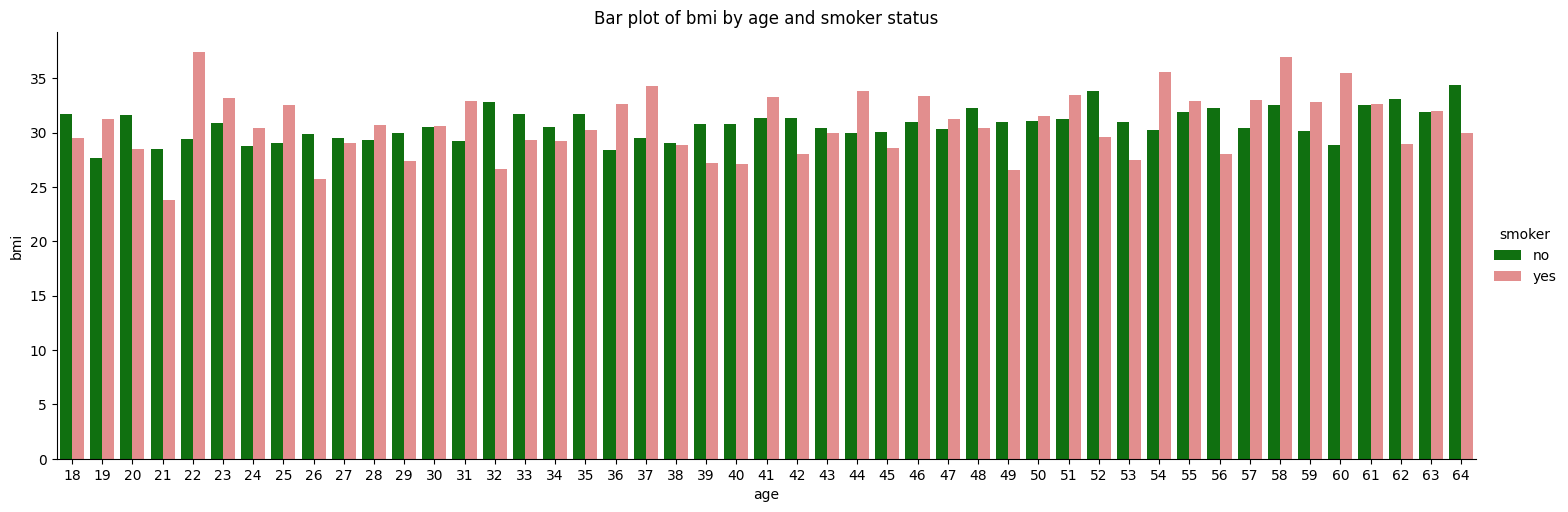

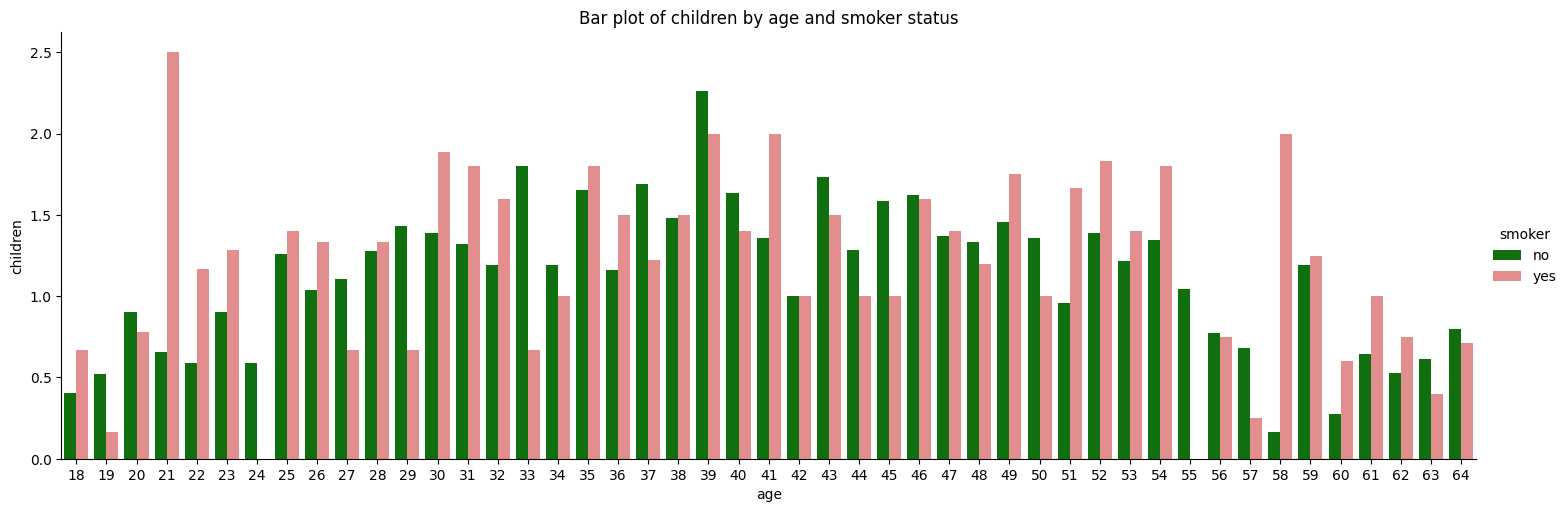

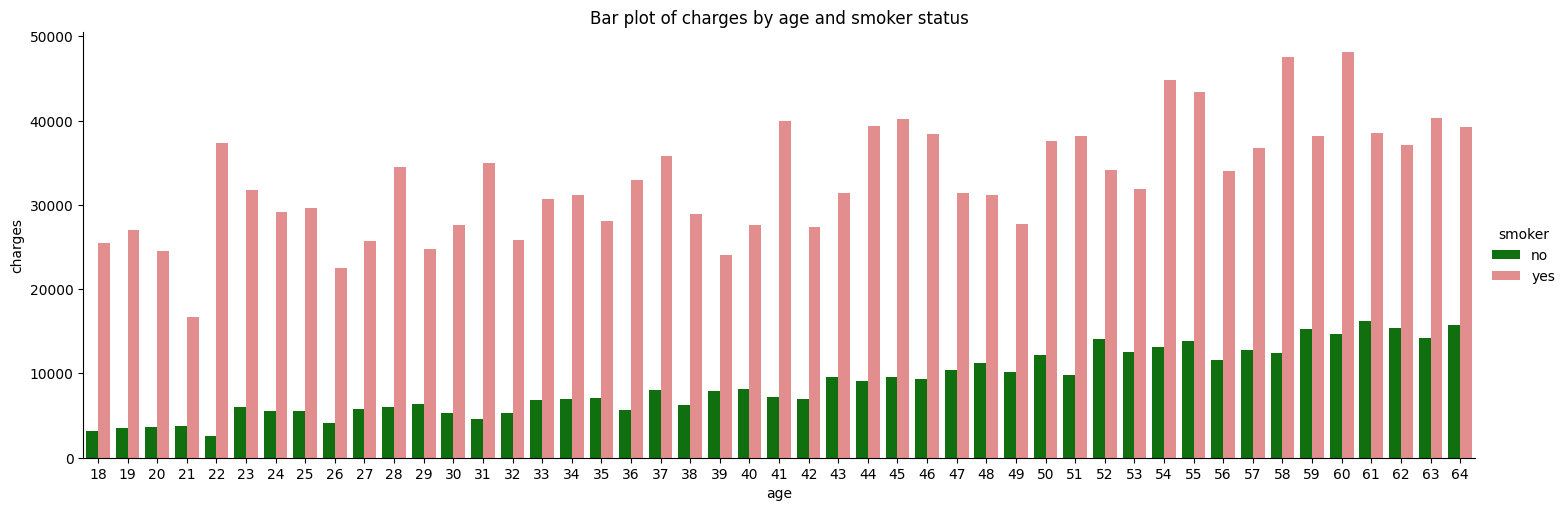

In [109]:
for i in df.select_dtypes('number').columns.drop(['age']):
    sns.catplot(x="age", y=i, data=df, hue='smoker', kind='bar', aspect=3, errorbar=None, palette=smoker_palette)
    plt.title(f'Bar plot of {i} by age and smoker status')
    plt.show()

Smokers usually have higher costs than non-smokers, so we can visualize the relationship between age, smoker status, and other numerical features in the dataset. The following code generates bar plots for each numerical feature against age, colored by smoker status.


In [110]:
df.isna().sum() # a perfect data

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [111]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

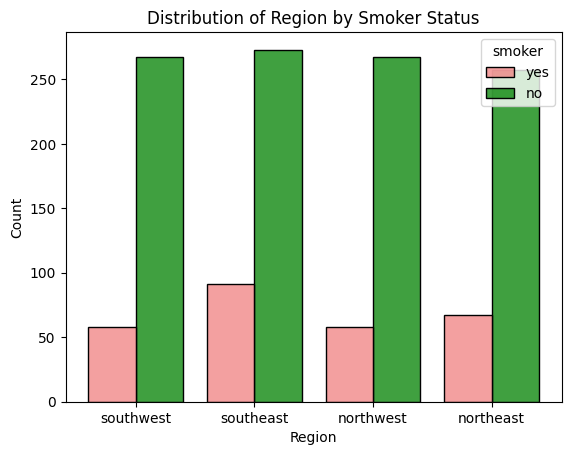

In [112]:
sns.histplot(data=df, x='region', hue='smoker', multiple='dodge', shrink=0.8, edgecolor='black', palette=smoker_palette)
plt.title('Distribution of Region by Smoker Status')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

In [113]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [114]:
df['health_condition'] = np.select(
    [
        (df['bmi'] < 18.5),  # Underweight
        (df['bmi'] >= 18.5) & (df['bmi'] < 24.9),  # Normal weight
        (df['bmi'] >= 24.9) & (df['bmi'] < 29.9),  # Overweight
        (df['bmi'] >= 29.9) & (df['bmi'] < 34.9),  # Obesity class I
        (df['bmi'] >= 34.9) & (df['bmi'] < 39.9),  # Obesity class II
        (df['bmi'] >= 39.9)  # Obesity class III
    ],
    [
        'Underweight',   'Normal weight', 'Overweight', 'Obesity class I',
        'Obesity class II', 'Obesity class III'],
    default = 'Unknown'
)

In [115]:
df['health_condition'].value_counts()

health_condition
Obesity class I      399
Overweight           377
Obesity class II     226
Normal weight        222
Obesity class III     94
Underweight           20
Name: count, dtype: int64

In [128]:
high_risk_conditions = df[(df['bmi'] >= 29.9) & (df['smoker'] == 'yes')]
np.mean(high_risk_conditions['charges'])
low_risk_conditions = df[(df['bmi'] < 29.9) & (df['smoker'] == 'no')]
np.mean(low_risk_conditions['charges'])

np.float64(8002.59602379878)

<Axes: xlabel='charges', ylabel='Density'>

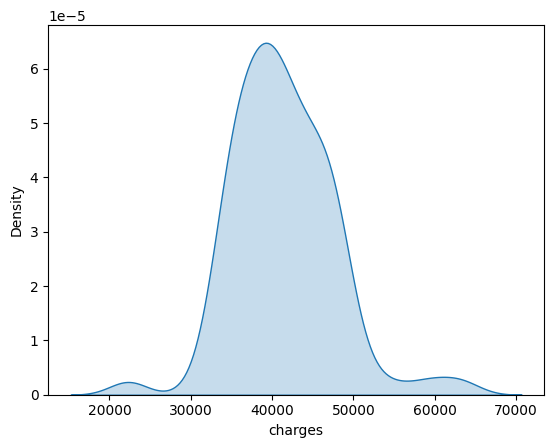

In [124]:
sns.kdeplot(data=high_risk_conditions, x='charges', fill=True)

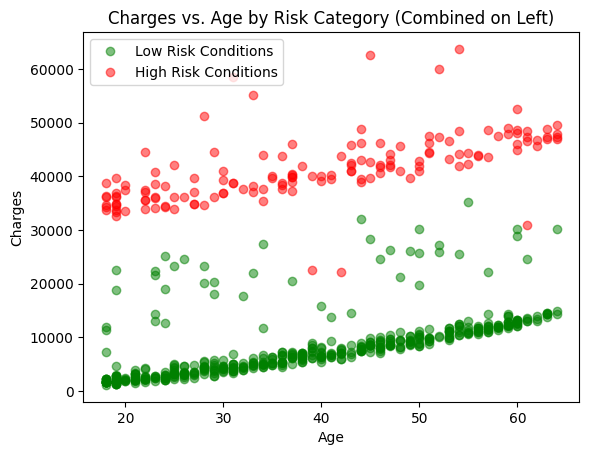

In [134]:
fig, ax = plt.subplots()
ax.plot(low_risk_conditions['age'], low_risk_conditions['charges'],
           'o', alpha=0.5, label='Low Risk Conditions', color='green')
ax.plot(high_risk_conditions['age'], high_risk_conditions['charges'],
           'o', alpha=0.5, label='High Risk Conditions', color='red')
ax.set_xlabel('Age')
ax.set_ylabel('Charges')
ax.set_title('Charges vs. Age by Risk Category (Combined on Left)')
ax.legend()


Here we can see the group who have higher bmi and are smokers, has a high average charge. On the other hand, the group with lower bmi and non-smokers has a lower average charge. This suggests that both smoking status and bmi are significant factors in determining insurance charges.